# Pairwise pair + rank stats

Analyze the generated candidate pairs in `data/pairs/` and the annotated ranks in `data/pairwise_labels.jsonl`.


In [7]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PAIRS_DIR = DATA_DIR / "pairs"
PAIRWISE_LABELS_PATH = DATA_DIR / "pairwise_labels.jsonl"
PAIRWISE_MANIFEST_DIR = DATA_DIR / "manifests" / "score_prediction_rank"

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)


In [8]:
def load_created_pairs(pairs_dir: Path) -> pd.DataFrame:
    rows: list[dict] = []
    for path in sorted(pairs_dir.glob("*.json")):
        payload = json.loads(path.read_text())
        data = payload.get("data") or {}
        rows.append(
            {
                "pair_file": path.name,
                "trick": data.get("trick"),
                "left": data.get("left"),
                "right": data.get("right"),
            }
        )
    if not rows:
        raise FileNotFoundError(f"No created pair files found in {pairs_dir}")
    return pd.DataFrame(rows)


def load_ranked_pairs(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing pairwise labels file: {path}")
    return pd.read_json(path, lines=True)


def load_pairwise_manifest_splits(manifest_dir: Path) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for split in ["train", "val", "test"]:
        path = manifest_dir / f"{split}.jsonl"
        if not path.exists():
            continue
        df = pd.read_json(path, lines=True)
        df["split"] = split
        rows.append(df)
    if not rows:
        raise FileNotFoundError(f"No pairwise manifests found in {manifest_dir}")
    return pd.concat(rows, ignore_index=True)


def build_clip_appearance_counts(
    pairs_df: pd.DataFrame, *, left_col: str = "left", right_col: str = "right"
) -> pd.DataFrame:
    left_counts = (
        pairs_df[left_col]
        .value_counts(dropna=False)
        .rename_axis("clip")
        .rename("left_count")
    )
    right_counts = (
        pairs_df[right_col]
        .value_counts(dropna=False)
        .rename_axis("clip")
        .rename("right_count")
    )
    counts = pd.concat([left_counts, right_counts], axis=1).fillna(0).astype(int)
    counts["total_count"] = counts["left_count"] + counts["right_count"]
    return counts.sort_values(["total_count", "left_count", "right_count"], ascending=False)


In [9]:
created_pairs_df = load_created_pairs(PAIRS_DIR)
ranked_pairs_df = load_ranked_pairs(PAIRWISE_LABELS_PATH)
manifest_df = load_pairwise_manifest_splits(PAIRWISE_MANIFEST_DIR)

created_clip_counts = build_clip_appearance_counts(created_pairs_df)
ranked_clip_counts = build_clip_appearance_counts(ranked_pairs_df)


In [10]:
print(f"created candidate pairs: {len(created_pairs_df):,}")
print(f"ranked pair labels: {len(ranked_pairs_df):,}")
print(f"pairwise manifest rows: {len(manifest_df):,}")
print()
print(f"unique clips in created candidate pairs: {created_clip_counts.index.nunique():,}")
print(f"unique clips in ranked pair labels: {ranked_clip_counts.index.nunique():,}")
print()
print("created pairs by trick:")
display(created_pairs_df["trick"].value_counts().rename_axis("trick").to_frame("pair_count"))
print("ranked pairs by trick:")
display(ranked_pairs_df["trick"].value_counts().rename_axis("trick").to_frame("rank_count"))
print("manifest rows by split:")
display(manifest_df["split"].value_counts().rename_axis("split").to_frame("row_count"))


created candidate pairs: 2,210
ranked pair labels: 174
pairwise manifest rows: 63

unique clips in created candidate pairs: 570
unique clips in ranked pair labels: 82

created pairs by trick:


,pair_count
trick,
bs-royale,365
fs-savanah,336
soul,323
fs-royale,313
ao-soul,310
mizou,285
top-soul,278


ranked pairs by trick:


,rank_count
trick,
ao-soul,172
soul,1
fs-savannah,1


manifest rows by split:


,row_count
split,
train,49
val,7
test,7


In [11]:
coverage_by_trick = (
    created_pairs_df["trick"].value_counts().rename("created_pairs")
    .to_frame()
    .join(ranked_pairs_df["trick"].value_counts().rename("ranked_pairs"), how="outer")
    .fillna(0)
    .astype(int)
)
coverage_by_trick["rank_coverage_pct"] = (
    100 * coverage_by_trick["ranked_pairs"] / coverage_by_trick["created_pairs"]
).round(2)
display(coverage_by_trick.sort_values("created_pairs", ascending=False))


,created_pairs,ranked_pairs,rank_coverage_pct
trick,,,
bs-royale,365,0,0.00
fs-savanah,336,0,0.00
soul,323,1,0.31
fs-royale,313,0,0.00
ao-soul,310,172,55.48
mizou,285,0,0.00
top-soul,278,0,0.00
fs-savannah,0,1,inf


In [12]:
print("Created-pair clip appearance summary")
display(created_clip_counts["total_count"].describe().to_frame("value"))
print("Ranked-pair clip appearance summary")
display(ranked_clip_counts["total_count"].describe().to_frame("value"))

print("Most frequent clips in created candidate pairs")
display(created_clip_counts.head(20))
print("Most frequent clips in ranked pairs")
display(ranked_clip_counts.head(20))


Created-pair clip appearance summary


,value
count,570.000000
mean,7.754386
std,1.709898
min,4.000000
25%,7.000000
50%,8.000000
75%,9.000000
max,13.000000


Ranked-pair clip appearance summary


,value
count,82.000000
mean,4.243902
std,2.848266
min,1.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,13.000000


Most frequent clips in created candidate pairs


,left_count,right_count,total_count
clip,,,
s3://aitraf/clips/25-11-02 19-14-55 5695-00.04.40.326-00.04.45.352-seg20.mp4,11,2,13
s3://aitraf/clips/25-11-17 21-01-19 5741-00.12.55.391-00.12.59.396-seg33.mp4,9,4,13
s3://aitraf/clips/25-11-07 16-03-18 5701-00.11.28.251-00.11.33.746-seg20.mp4,8,5,13
s3://aitraf/clips/25-12-01 21-27-45 5969-00.02.43.993-00.02.49.051-seg3.mp4,7,6,13
s3://aitraf/clips/25-11-02 19-14-55 5695-00.03.37.614-00.03.41.105-seg14.mp4,11,1,12
s3://aitraf/clips/25-11-15 18-42-16 5731-00.08.26.303-00.08.30.252-seg17.mp4,6,6,12
s3://aitraf/clips/25-11-15 19-11-43 5734-00.00.33.758-00.00.37.349-seg01.mp4,6,6,12
s3://aitraf/clips/25-11-15 19-11-43 5734-00.01.55.706-00.01.59.957-seg04.mp4,6,6,12
s3://aitraf/clips/25-11-17 21-54-30 5744-00.01.30.070-00.01.34.442-seg03.mp4,6,6,12


Most frequent clips in ranked pairs


,left_count,right_count,total_count
clip,,,
s3://aitraf/clips/25-11-02 19-14-55 5695-00.04.40.326-00.04.45.352-seg20.mp4,11,2,13
s3://aitraf/clips/25-11-02 19-14-55 5695-00.03.37.614-00.03.41.105-seg14.mp4,11,1,12
s3://aitraf/clips/25-10-31 19-54-19 5689-00.02.24.842-00.02.30.421-seg04.mp4,10,0,10
s3://aitraf/clips/25-11-07 15-47-00 5699-00.11.05.484-00.11.09.955-seg18.mp4,7,3,10
s3://aitraf/clips/25-11-02 19-14-55 5695-00.14.22.562-00.14.26.871-seg50.mp4,5,5,10
s3://aitraf/clips/25-11-02 19-14-55 5695-00.05.54.650-00.05.58.815-seg27.mp4,8,1,9
s3://aitraf/clips/25-11-02 19-14-55 5695-00.12.43.443-00.12.48.351-seg44.mp4,7,2,9
s3://aitraf/clips/25-11-02 19-14-55 5695-00.04.46.343-00.04.50.799-seg21.mp4,8,0,8
s3://aitraf/clips/25-11-07 16-17-23 5702-00.02.36.390-00.02.42.855-seg2.mp4,7,1,8


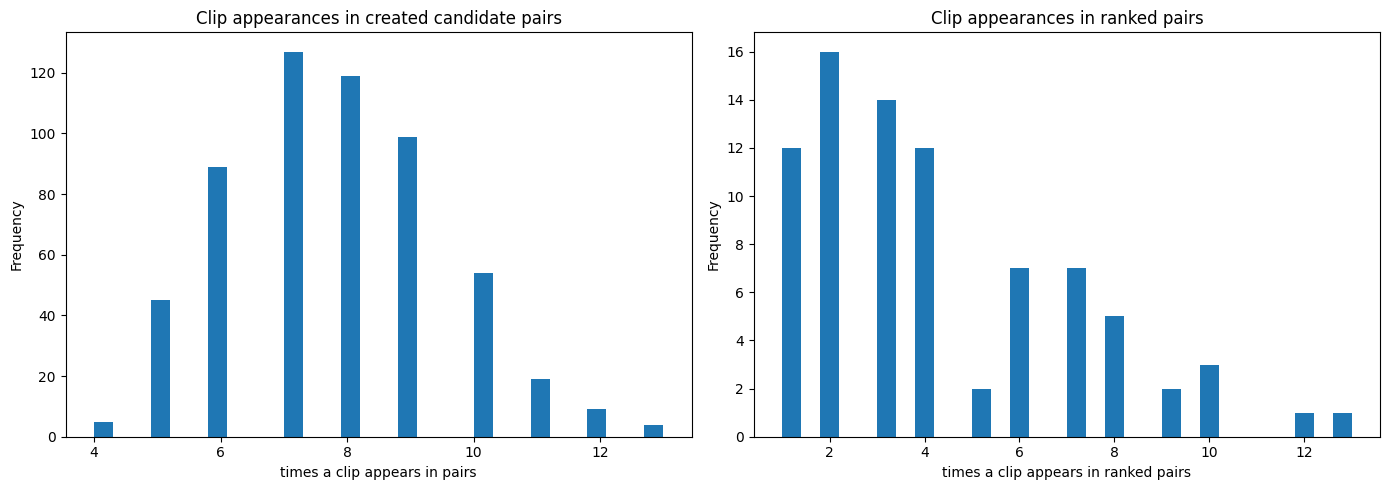

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

created_clip_counts["total_count"].plot.hist(
    bins=30,
    ax=axes[0],
    title="Clip appearances in created candidate pairs",
)
axes[0].set_xlabel("times a clip appears in pairs")

ranked_clip_counts["total_count"].plot.hist(
    bins=30,
    ax=axes[1],
    title="Clip appearances in ranked pairs",
)
axes[1].set_xlabel("times a clip appears in ranked pairs")

plt.tight_layout()


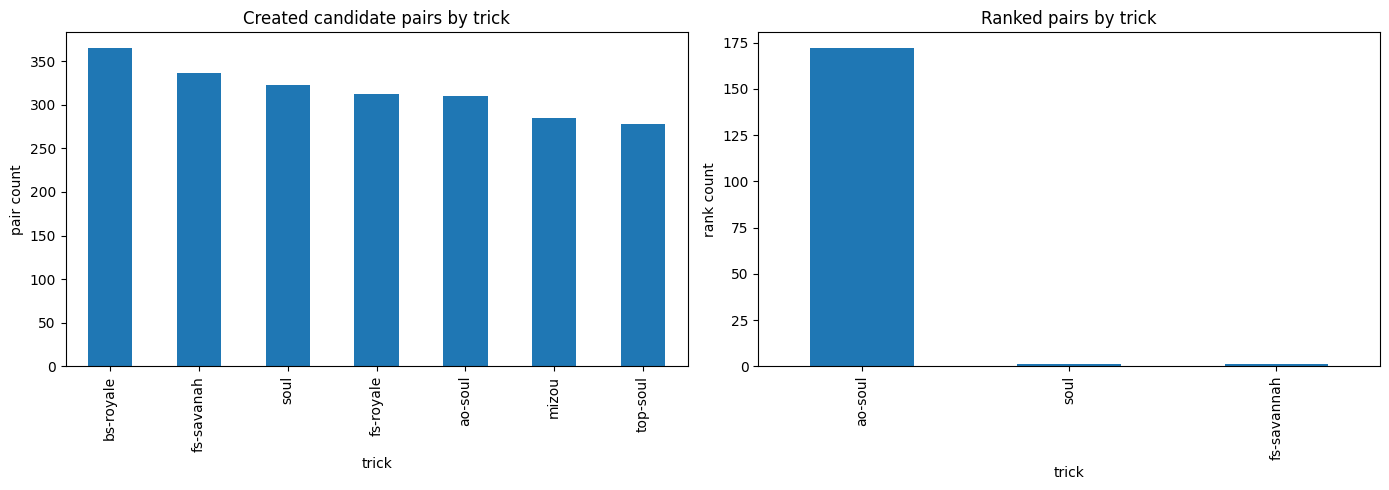

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

created_pairs_df["trick"].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[0],
    title="Created candidate pairs by trick",
)
axes[0].set_ylabel("pair count")

ranked_pairs_df["trick"].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[1],
    title="Ranked pairs by trick",
)
axes[1].set_ylabel("rank count")

plt.tight_layout()


In [15]:
print("Preference balance overall")
display(ranked_pairs_df["pref"].value_counts().rename_axis("pref").to_frame("count"))

print("Preference balance by trick")
display(
    ranked_pairs_df.groupby("trick")["pref"]
    .value_counts()
    .rename("count")
    .reset_index()
    .pivot(index="trick", columns="pref", values="count")
    .fillna(0)
    .astype(int)
)


Preference balance overall


,count
pref,
left,93
right,79


Preference balance by trick


pref,left,right
trick,,
ao-soul,93,77
fs-savannah,0,1
soul,0,1


In [16]:
created_left_right_balance = pd.DataFrame(
    {
        "left_role": created_clip_counts["left_count"],
        "right_role": created_clip_counts["right_count"],
    }
)
created_left_right_balance["left_minus_right"] = (
    created_left_right_balance["left_role"] - created_left_right_balance["right_role"]
)

print("Clips with the strongest left/right imbalance in created candidate pairs")
display(
    created_left_right_balance.reindex(
        created_left_right_balance["left_minus_right"].abs().sort_values(ascending=False).index
    ).head(20)
)


Clips with the strongest left/right imbalance in created candidate pairs


,left_role,right_role,left_minus_right
clip,,,
s3://aitraf/clips/IMG_5680-00.02.30.185-00.02.36.031-seg4.mp4,0,12,-12
s3://aitraf/clips/IMG_5683-00.05.10.739-00.05.16.783-seg09.mp4,0,12,-12
s3://aitraf/clips/IMG_5678-00.02.14.873-00.02.20.717-seg5.mp4,0,11,-11
s3://aitraf/clips/25-10-31 19-46-26 5688-00.05.22.274-00.05.27.599-seg17.mp4,11,0,11
s3://aitraf/clips/25-10-31 19-54-19 5689-00.07.04.659-00.07.09.411-seg14.mp4,11,0,11
s3://aitraf/clips/25-11-02 19-14-55 5695-00.01.06.816-00.01.11.286-seg03.mp4,10,0,10
s3://aitraf/clips/25-11-07 16-03-18 5701-00.02.13.147-00.02.17.834-seg02.mp4,10,0,10
s3://aitraf/clips/IMG_5682-00.04.08.683-00.04.14.712-seg6.mp4,0,10,-10
s3://aitraf/clips/IMG_5679-00.00.59.886-00.01.04.106-seg3.mp4,0,10,-10
